In [1]:
print("hello")

hello


In [2]:
import cadquery as cq
from jupyter_cadquery import show
import numpy
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

Overwriting auto display for cadquery Workplane and Shape


In [3]:
def create_triangle_outline(part, outer_thickness=1):
    
    bbox = part.val().BoundingBox()
    
    def outline_line(inp, return_z = True):
        slope = (bbox.zmax - bbox.zmin)/(bbox.xmax - bbox.xmin)
        new_intercept = bbox.zmax - outer_thickness * 2    
        
        if return_z:
            return slope * inp + new_intercept
        else:
            return (inp - new_intercept)/slope
            
    
    inner = (
        cq.Workplane("XZ")
        .polyline([(-outer_thickness, outer_thickness), 
                   (-outer_thickness,outline_line(-outer_thickness)), 
                   (outline_line(outer_thickness, return_z = False), outer_thickness)])
        .close()
        .extrude(-5)
    )
    
    hollow_triangle = part.cut(inner)
    inner_vol = max([f.Area() for f in inner.faces().vals()]) * (bbox.ymax - bbox.ymin)
    
    return hollow_triangle, inner, inner_vol



In [4]:
def get_finray_infill(part, density = 25, spacing = 0, rod_diameter = 0.45, outline_thickness = 0.87):

    width = 70
    depth = 70
    thickness = 20

    outline, inner, inner_vol = create_triangle_outline(part, outer_thickness=outline_thickness)
    
    a = 70.353
    b = -0.618
    c = 4.369

    if spacing == 0:
        spacing = density_to_spacing(density, a, b, c)

    grid = cq.Workplane("XZ")

    x = -width/2
    while x <= width/2:
        grid = grid.union(
            cq.Workplane("XZ").center(x, 25)
            .rect(rod_diameter, depth) 
            .extrude(-thickness)         
        )
        x += spacing

    grid = grid.rotate((0, 0, 0), (0, 1, 0), -45)
    
    infill_inside = grid.intersect(inner)
    
    result = outline.union(infill_inside)
    infill_volume = infill_inside.val().Volume()

    
    
    return result, infill_volume/inner_vol * 100
    
    
    

In [5]:
def get_grid_infill(part, density = 50, rod_diameter = 0.45, spacing = 0, outline_thickness = 0.87):
    
    width = 80  
    depth = 80   
    thickness = 20  

    outline, inner, inner_vol = create_triangle_outline(part, outer_thickness=outline_thickness)

    a = 67.110
    b = -0.372
    c = 6.856

    if spacing == 0:
        spacing = density_to_spacing(density, a, b, c)
    
    grid = cq.Workplane("XZ") 
    
    x = 0
    while x >= -width/2:
        grid = grid.union(
            cq.Workplane("XZ").center(x, 25)
            .rect(rod_diameter, depth) 
            .extrude(-thickness)         
        )
        x -= spacing
    
    z = -depth/2
    while z <= depth/5:
        grid = grid.union(
            cq.Workplane("XZ").center(0, z+25)
            .rect(width, rod_diameter)  
            .extrude(-thickness)         
        )
        z += spacing
    
    grid = grid.rotate((0, 0, 0), (0, 1, 0), 45)
    infill_inside = grid.intersect(inner)
    result = outline.union(infill_inside)
    
    infill_volume = infill_inside.val().Volume()
    
    return result, infill_volume/inner_vol * 100





In [6]:
import math

def get_triangle_infill(part, spacing = 0, density = 50, rod_diameter = 0.45, outline_thickness = 0.87):
    
    thickness = 20  

    outline, inner, inner_vol = create_triangle_outline(part, outer_thickness=outline_thickness)

    a = 90.017
    b = -0.354
    c = 9.913

    if (spacing == 0):
        spacing = density_to_spacing(density, a, b, c)
        
    width = (math.ceil(25/spacing) * spacing) * 2 
    depth = (math.ceil(25/spacing) * spacing) * 2  
    
    grid = cq.Workplane("XZ")
    
    x = -width/2
    while x <= width/2:
        grid = grid.union(
            cq.Workplane("XZ").center(x, 3)
            .rect(rod_diameter, depth) 
            .extrude(-thickness)         
        )
        x += spacing

    grid = grid.rotate((0, 0, 0), (0, 1, 0), -90)

    grid_tri_one = cq.Workplane("XZ")

    x = -width/2
    while x <= width/2:
        grid_tri_one = grid_tri_one.union(
            cq.Workplane("XZ").center(x, 3)
            .rect(rod_diameter, depth) 
            .extrude(-thickness)         
        )
        x += spacing
        
    grid_tri_one = grid_tri_one.rotate((0, 0, 0), (0, 1, 0), 30)

    grid_tri_two = cq.Workplane("XZ")

    x = -width/2
    while x <= width/2:
        grid_tri_two = grid_tri_two.union(
            cq.Workplane("XZ").center(x, 3)
            .rect(rod_diameter, depth) 
            .extrude(-thickness)         
        )
        x += spacing
        
    grid_tri_two = grid_tri_two.rotate((0, 0, 0), (0, 1, 0), -30)

    grid_tri = grid_tri_two.union(grid_tri_one)
    grid = grid.union(grid_tri)

    grid = grid.translate((10, 0, 10))
    
    grid = grid.rotate((0, 0, 0), (0, 1, 0), -45)

    infill_inside = grid.intersect(inner)

    result = outline.union(infill_inside)
    infill_volume = infill_inside.val().Volume()
    
    return result, infill_volume/inner_vol * 100

In [7]:

def hexagon_func(side_length, thickness, cut=True):
    pts = []
    for i in range(6):
        angle = math.radians(60 * i)
        pts.append((math.cos(angle) * side_length,
                    math.sin(angle) * side_length))
    
    hexagon = cq.Workplane("XZ").polyline(pts + [pts[0]]).close().extrude(-10)
    hexagon = hexagon.rotate((0,0,0), (0, 1, 0), 30)
    if cut:
        hexagon = hexagon.cut(hexagon_func(side_length-thickness, thickness, cut=False))
        
    return hexagon
    
def get_honeycomb_infill(part, side_length = 0, density = 20, rod_diameter = 0.45, outline_thickness = 0.87):

    outline, inner, inner_area = create_triangle_outline(part, outer_thickness=outline_thickness)

    a = 67.000
    b = -0.380
    c = 4.915

    if (side_length == 0):
        side_length = density_to_spacing(density, a, b, c)
    
    width = 50
    layers = math.ceil(36/(side_length))
    thickness = 10
    grid = cq.Workplane("XZ")
    space = math.sin(math.pi/3) * side_length
    
    for layer in range(layers):
        
        x = 0
        spacing = (math.cos(math.pi / 6) * side_length- (rod_diameter / 2)) if layer % 2 == 1 else 0
        while x >= -width/2:
            grid = grid.union(hexagon_func(side_length, rod_diameter).
                translate((x + spacing, 0, 36 - layer * (1.5 * side_length - rod_diameter))))
            x -= space*2 - rod_diameter


    grid = grid.rotate((0, 0, 0), (0, 1, 0), 15)
    
    infill_inside = grid.intersect(part)
    
    result = outline.union(infill_inside)
    infill_volume = infill_inside.val().Volume()

    return result, infill_volume / inner_area * 100


In [8]:
def density_to_spacing(y, a, b, c):
    if (y - c) / a <= 0:
        raise ValueError("Invalid input")
    return (1 / b) * np.log((y - c) / a)

In [13]:

triangle_outline_thickness = 0.87
infill_thickness = 0.45
honeycomb_thickness = 0.65


part = cq.importers.importStep("STEP_files/GripperForOpt_v2.step")
infill, density = honeycomb_infill(part, density = 10.0, 
                       honeycomb_thickness = infill_thickness, 
                       outline_thickness=triangle_outline_thickness)
print(density)
show(infill)


NameError: name 'honeycomb_infill' is not defined

In [52]:
xcoords, ycoords = [], []

for spacing in numpy.arange(2, 15.5, 0.5):
    infill, density = get_honeycomb_infill(part, side_length = spacing, rod_diameter = infill_thickness)
    xcoords.append(spacing)
    ycoords.append(density)



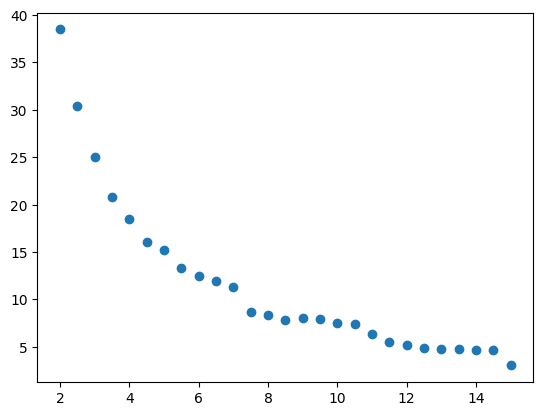

In [53]:
plt.scatter(xcoords, ycoords)


y = 67.000 * e^(-0.380x) + 4.915


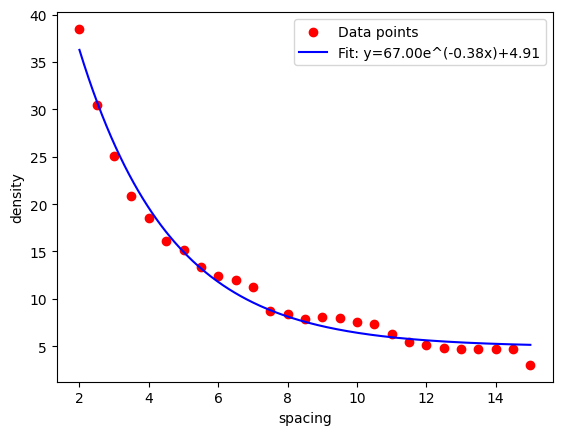

In [54]:
import numpy as np
from scipy.optimize import curve_fit

x = numpy.array(xcoords)
y = numpy.array(ycoords)

def exp_decay(x, a, b, c):
    return a * np.exp(b * x) + c

params, _ = curve_fit(exp_decay, x, y, p0=(50, -0.4, 8))
a, b, c = params

print(f"y = {a:.3f} * e^({b:.3f}x) + {c:.3f}")

x_fit = np.linspace(min(x), max(x), 300)
y_fit = exp_decay(x_fit, a, b, c)

plt.scatter(x, y, color="red", label="Data points")
plt.plot(x_fit, y_fit, color="blue", label=f"Fit: y={a:.2f}e^({b:.2f}x)+{c:.2f}")
plt.legend()
plt.xlabel("spacing")
plt.ylabel("density")
plt.show()


In [79]:
density_to_spacing(40, a, b, c)

np.float64(2.7098429059679887)